In [1]:
# from modules import *
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from obspy.geodetics.base import gps2dist_azimuth,degrees2kilometers,locations2degrees
import pygmt
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
from scipy.spatial import KDTree
from shapely.geometry import LineString, Point
from scipy.signal import detrend
import pygeodesy
from pygeodesy.ellipsoidalKarney import LatLon
ginterpolator = pygeodesy.GeoidKarney("/Users/charlesh/Documents/Codes/OBS_Methods/NOISE/Research/Notebooks/egm2008-5.pgm")
geoid= lambda lat,lon: ginterpolator(LatLon(lat, lon))
datafolder = Path('/Users/charlesh/Documents/Codes/OBS_Methods/NOISE/Research/Notebooks/632.Galapagos.GravData')
gravdatafile = datafolder/'Processed_Daily_Grav'/'grv_all_sat.txt'
line_points = np.array([[-98, 2.749885], [-90.907174, 1.849262], [-90.707551, 0.921334], [-85.379041, 0.633260]])
def ridge_distance(lola):
    line_points = np.array([[-98, 2.749885], [-90.907174, 1.849262], [-90.707551, 0.921334], [-85.379041, 0.633260]])
    line = LineString(line_points)
    point = Point(lola)
    closest_point_on_line = line.interpolate(line.project(point))
    shortest_distance, _, _ = gps2dist_azimuth(lola[1], lola[0], closest_point_on_line.y, closest_point_on_line.x)
    p=-1 if point.y>closest_point_on_line.y else 1
    # print(f"Closest point on the line: {closest_point_on_line}")
    # print(f"Shortest distance to the line: {shortest_distance:.2f} meters")
    return p*shortest_distance

wgs84 = lambda lat,a=6378.137,f=1/298.257222:a*((1+(((2*f)-(f**2))/((1-f)**2)) * (np.sin(np.deg2rad(lat)))**2  )**(-0.5))

In [2]:
column_names = ['Lon', 'Lat', 'mgal', '4', 'free_air', 'Bathymetry', '7', '8']
figsize=(6,6)
data=pd.read_csv(gravdatafile,delim_whitespace=True,header=None,names=column_names)
df=data[['Lon', 'Lat', 'mgal', 'free_air','Bathymetry']].copy()

# BATHYMETRY
grd_file = str(datafolder/'Maps'/'regional.grd')
grid_data = pygmt.grd2xyz(grd_file, output_type="pandas");grid_data = grid_data[~grid_data.z.isna()]
df['GeoidHeight']=[geoid(a.Lat,a.Lon) for a in df.iloc]
df['EllipsoidHeight']=[wgs84(a.Lat) for a in df.iloc]
df['RidgeDistance_km'] = [ridge_distance(lola)/1000 for lola in (np.array([df.Lon,df.Lat]).T)]

# Path length
dx=[0];dx.extend([degrees2kilometers(locations2degrees(s.Lat,s.Lon,e.Lat,e.Lon)) for s,e in zip(df.iloc[:-1].iloc,df.iloc[1:].iloc)])
# There is two rows that define where the grav-data is discontinuous, remove them. (turned off/on when first arriving from Quito?)
df['Path']=dx
df = df[df.Path<2].copy()
df['Path'] = df.Path.cumsum()

#Clear bad values at top of file
df=df.iloc[9:] # Only the first 9 values in the free-air anomaly file are very odd or set to NaN, so let's remove them.

/var/folders/4c/3xb25hld3w73hv1lxgbg7r9m0000gn/T/ipykernel_80227/658674877.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data=pd.read_csv(gravdatafile,delim_whitespace=True,header=None,names=column_names)


/var/folders/4c/3xb25hld3w73hv1lxgbg7r9m0000gn/T/ipykernel_80227/3656960733.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('jet', colorres)


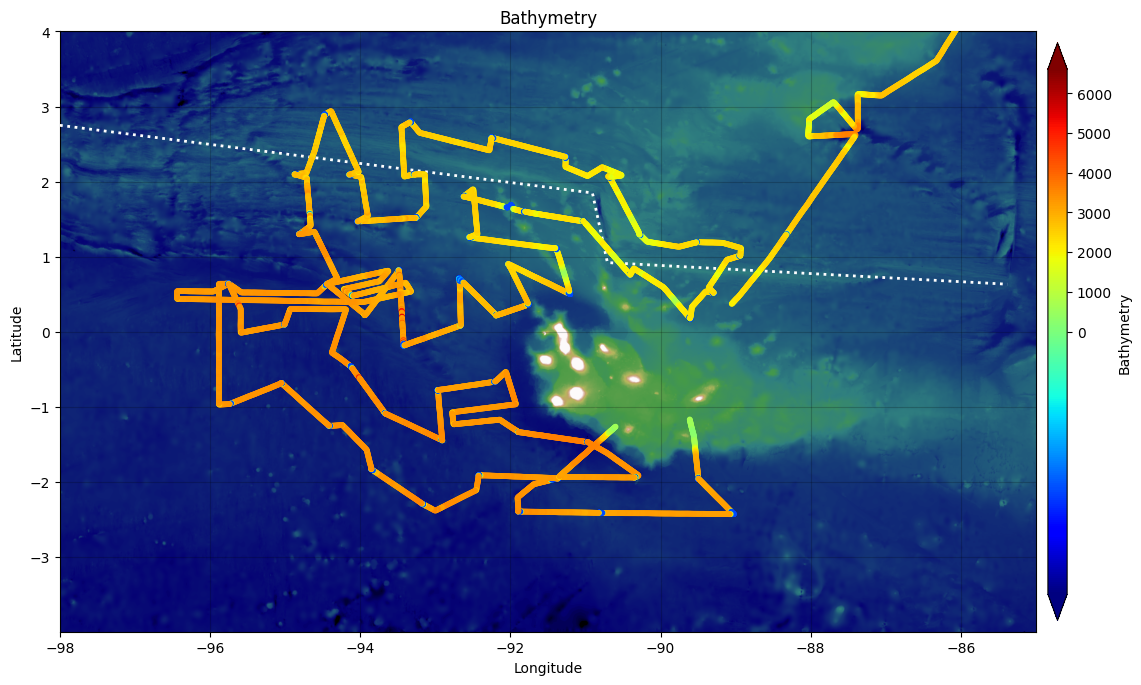

In [3]:
def df_map_free_air(colored='free_air',crossval=1,clim=None):
    grid = grid_data.pivot(index='y', columns='x', values='z')
    x,y,z= grid_data.x,grid_data.y,grid_data.z
    # Define a diverging normalization centered at zero
    norm = mcolors.TwoSlopeNorm(vmin=.6*grid.values.min(), vcenter=0, vmax=.3*grid.values.max())
    custom_cmap='gist_earth'
    # Plot the grid using imshow
    plt.figure(figsize=(15, 15))
    plt.imshow(grid.values,extent=[x.min(), x.max(), y.min(), y.max()],origin='lower',cmap=custom_cmap,norm=norm)
    # plt.colorbar(label='Elevation (m)', shrink=0.75, aspect=30)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(colored.replace('free_air','Free Air Anomaly'))
    plt.xlim([x.min(), x.max()])
    plt.ylim([y.min(), y.max()])
    plt.grid('major',alpha=.2,c='k')
    plt.plot(line_points[:, 0], line_points[:, 1], linewidth=2, color='w', zorder=10,linestyle=':')  # Adjust zorder to ensure it's on top

    # cmap = plt.cm.get_cmap('jet', 256)

    xx=df.Lon
    yy=df.Lat
    fillcolor = np.array([1, 0, 1, 1])  # RGBA for fillcolor
    zz=df[colored]
    if colored=='free_air':clim=[-20,20];clim_extended=[-150,150];crossval=0;colorres=20
    else:
        if clim==None:clim=[zz.min(),zz.max()];clim_extended=clim;colorres=256

    cmap = plt.cm.get_cmap('jet', colorres)
    vcenter=0 if ((df[colored].min()<0)&(df[colored].max()>0)) else zz.mean()
    colors = cmap(np.linspace(0, 1, colorres))
    idx = np.logical_and(np.linspace(clim_extended[0], clim_extended[1], colorres) >= -crossval,np.linspace(clim_extended[0], clim_extended[1], colorres) <= crossval)
    colors[idx] = fillcolor
    norm = mcolors.TwoSlopeNorm(vmin=clim[0], vcenter=vcenter, vmax=clim[1])
    cmap = ListedColormap(colors)
    sc=plt.scatter(xx,yy,s=10,c=zz,cmap=cmap,norm=norm,zorder=11)
    plt.gca().set_aspect('equal')
    if colored=='free_air':
        cbar = plt.colorbar(plt.scatter([],[],s=0,c=[],cmap=cmap,
        norm=mcolors.TwoSlopeNorm(vmin=clim_extended[0], vcenter=vcenter, vmax=clim_extended[1]),zorder=0),
        label='Free Air Anomaly, mGal', shrink=0.5, aspect=30, extend='both',pad=0.01)
        cbar.set_ticks([-150, -100, -50, -20, 0, 20, 50, 100, 150])
        cbar.set_ticklabels([-150, -100, -50, -20, 0, 20, 50, 100, 150])
    else:cbar = plt.colorbar(sc,norm=norm,label=colored, shrink=0.5, aspect=30, extend='both',pad=0.01)
df_map_free_air('Bathymetry',0)

/var/folders/4c/3xb25hld3w73hv1lxgbg7r9m0000gn/T/ipykernel_80227/679843466.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1],pad=0)


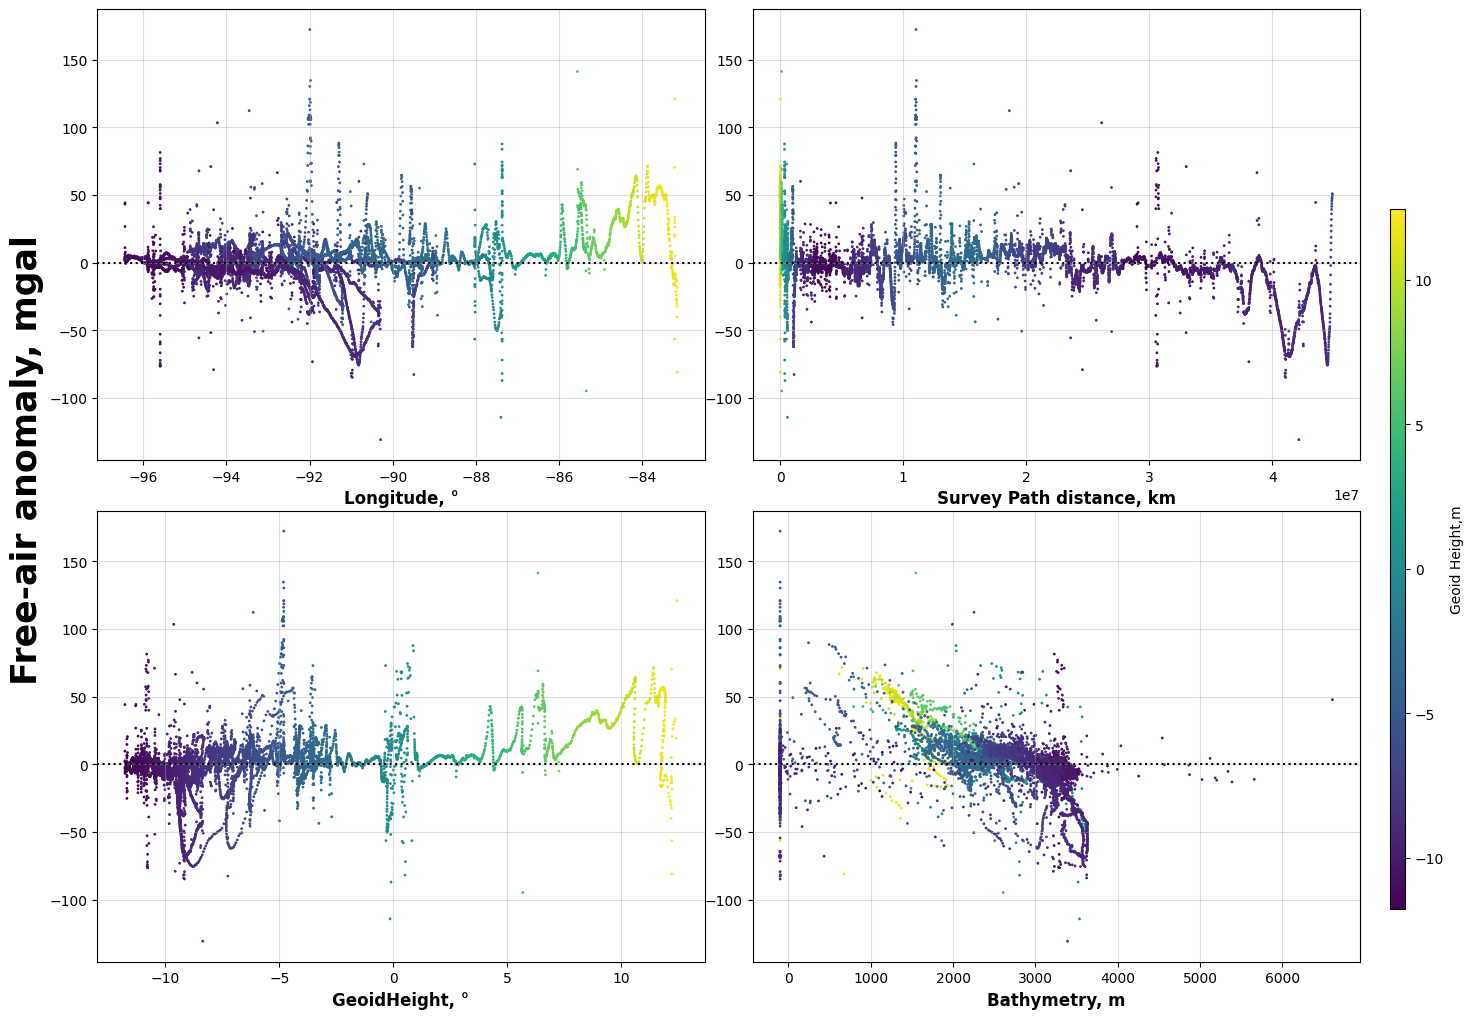

In [4]:
fontprops={'fontweight':'bold','fontsize':12}
figsize = (15,10)
colorkey='Bathymetry';colorlabel='Batymetry,m'
colorkey='GeoidHeight';colorlabel='Geoid Height,m'


fig,axes = plt.subplots(2,2,figsize=figsize)
axes=axes.reshape(-1)
ax = axes[0]
ax.scatter(df.Lon,df.free_air,s=1,c=df[colorkey].values)
ax.axhline(0,linestyle=':',c='k')
ax.grid(alpha=0.4)
ax.set_xlabel('Longitude, °',**fontprops)
ax.set_ylabel('Free-air anomaly, mgal',fontweight='bold',fontsize=25,horizontalalignment='right')
ax = axes[1]
ax.scatter(df.Path.cumsum(),df.free_air,s=1,c=df[colorkey].values)
ax.axhline(0,linestyle=':',c='k')
ax.grid(alpha=0.4)
ax.set_xlabel('Survey Path distance, km',**fontprops)
ax = axes[2]
sc1=ax.scatter(df.GeoidHeight,df.free_air,s=1,c=df[colorkey].values)
ax.axhline(0,linestyle=':',c='k')
ax.grid(alpha=0.4)
ax.set_xlabel('GeoidHeight, °',**fontprops)
ax = axes[3]
sc3=ax.scatter(df.Bathymetry.values,df.free_air,s=1,c=df[colorkey].values)
ax.axhline(0,linestyle=':',c='k')
ax.grid(alpha=0.4)
ax.set_xlabel('Bathymetry, m',**fontprops)
cbar_ax = fig.add_axes([0.92, 0.10, 0.01, 0.7])
fig.colorbar(sc3, cax=cbar_ax, label=colorlabel,aspect=90,shrink=.3)
plt.tight_layout(rect=[0, 0, 0.9, 1],pad=0)

In [5]:
df

,Lon,Lat,mgal,free_air,Bathymetry,GeoidHeight,EllipsoidHeight,RidgeDistance_km,Path
9,-83.2225,8.3900,978270.3,120.9,-99.000,12.443970,6377.679473,-890.474227,8.261649
10,-83.2233,8.3810,978168.1,19.3,-99.000,12.405252,6377.680447,-889.492119,9.266265
11,-83.2241,8.3719,978182.0,33.8,-99.000,12.367422,6377.681431,-888.499401,10.281959
12,-83.2249,8.3628,978180.2,31.6,-99.000,12.331033,6377.682413,-887.506723,11.297653
13,-83.2257,8.3535,978178.6,29.4,-99.000,12.295488,6377.683416,-886.492793,12.335504
...,...,...,...,...,...,...,...,...,...
10675,-90.6164,-1.2794,978044.5,47.8,510.561,-5.856122,6378.126285,242.450674,8138.961881
10676,-90.6121,-1.2758,978045.8,49.2,55.503,-5.797364,6378.126345,242.027509,8139.585375
10677,-90.6078,-1.2722,978046.4,51.0,318.926,-5.739991,6378.126405,241.604345,8140.208869
10678,-90.6034,-1.2682,978045.3,50.1,571.489,-5.680672,6378.126472,241.136417,8140.869992


In [6]:
df[colorkey].min()

-11.768500944934642

/var/folders/4c/3xb25hld3w73hv1lxgbg7r9m0000gn/T/ipykernel_80227/2477301594.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1],pad=0)


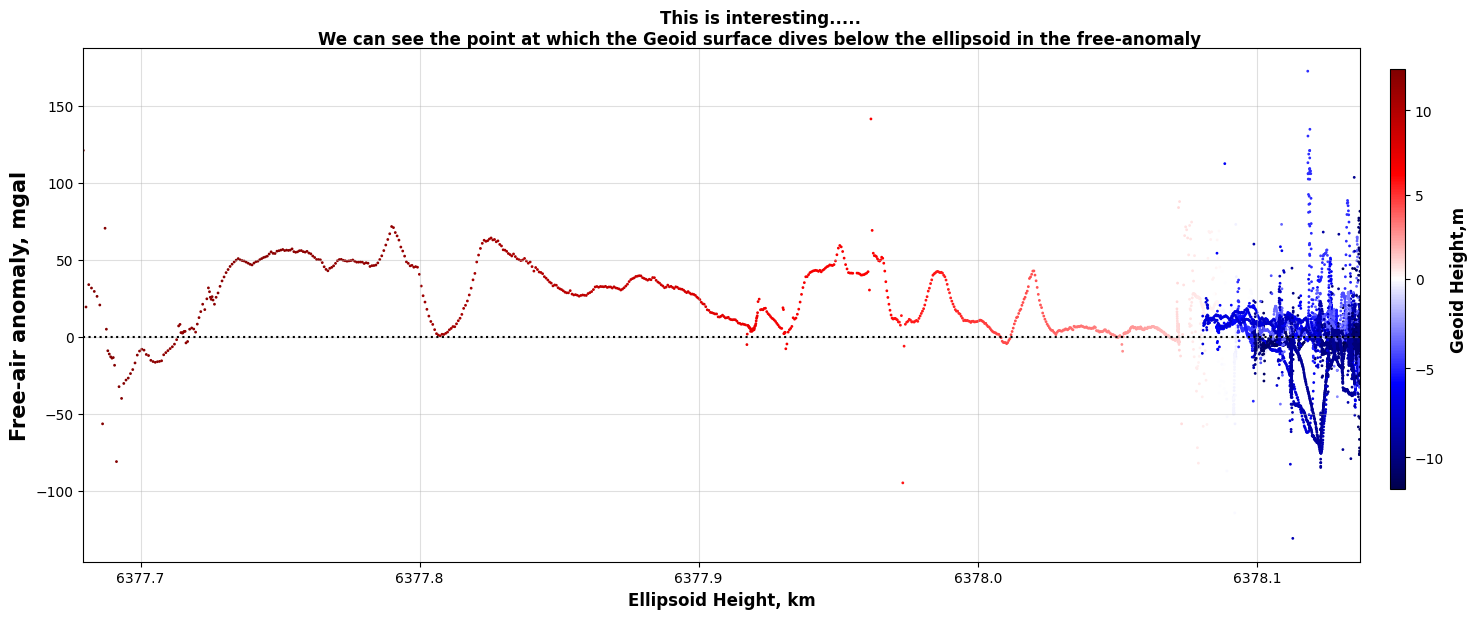

In [7]:
fontprops={'fontweight':'bold','fontsize':12}
figsize = (15,6)
# colorkey='Bathymetry';colorlabel='Batymetry,m'
colorkey='GeoidHeight';colorlabel='Geoid Height,m'

fig,axes = plt.subplots(1,1,figsize=figsize)

fig.suptitle('This is interesting.....\nWe can see the point at which the Geoid surface dives below the ellipsoid in the free-anomaly',y=1,**fontprops)

axes=np.atleast_2d(axes).reshape(-1)
ax = axes[0]
# norm = mcolors.TwoSlopeNorm(vmin=df[colorkey].min(), vcenter=df[colorkey].mean(), vmax=df[colorkey].max())
norm = mcolors.TwoSlopeNorm(vmin=df[colorkey].min(), vcenter=0, vmax=df[colorkey].max())
sc=ax.scatter(df.EllipsoidHeight,df.free_air,s=1,c=df[colorkey].values,norm=norm,cmap='seismic')
ax.axhline(0,linestyle=':',c='k')
ax.grid(alpha=0.4)
ax.set_xlabel('Ellipsoid Height, km',**fontprops)
ax.set_ylabel('Free-air anomaly, mgal',fontweight='bold',fontsize=15,horizontalalignment='center')
ax.set_xlim(df.EllipsoidHeight.min(),df.EllipsoidHeight.max())
# ax.set_xlim(left=6377.9)
cbar_ax = fig.add_axes([0.92, 0.20, 0.01, 0.7])
cb=fig.colorbar(sc, cax=cbar_ax, label=colorlabel,aspect=90,shrink=.3)
plt.tight_layout(rect=[0, 0, 0.9, 1],pad=0)
cb.ax.set_ylabel(colorlabel, fontsize=12, fontweight='bold')  # Label font size
cb.ax.tick_params(labelsize=10)  # Tick label font size

In [85]:
# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====
# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====
# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====# ====XXXX====

df=pd.read_csv(file,delim_whitespace=True,header=None,names=['distkm','BGmGal'])
df['distkm']=(df.distkm - df[df.BGmGal==df.BGmGal.min()].distkm.iloc[0]) - 20

/var/folders/4c/3xb25hld3w73hv1lxgbg7r9m0000gn/T/ipykernel_80227/1249168393.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df=pd.read_csv(file,delim_whitespace=True,header=None,names=['distkm','BGmGal'])


In [205]:
drho

600

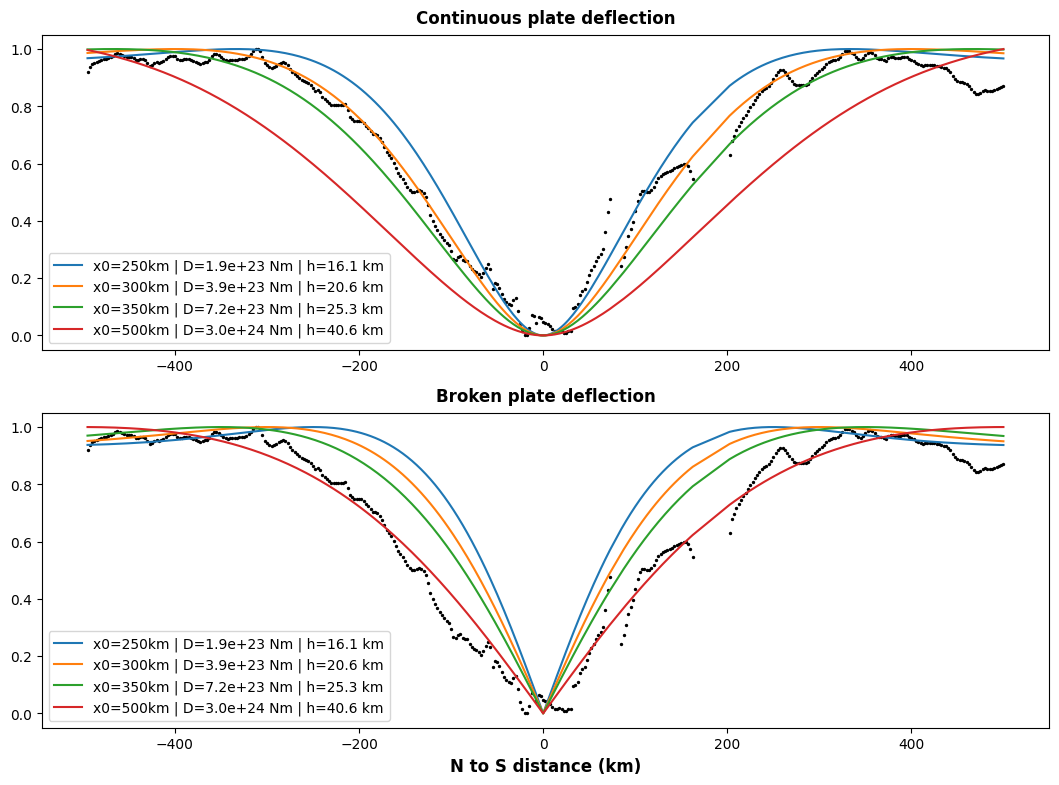

In [215]:
fontprops={'fontweight':'bold','fontsize':12}
file=datafolder/'boug_profile.xb'
# figsize=(6,6)
figsize=(13,9)
fig,axes=plt.subplots(2,1,figsize=figsize)
axes = np.atleast_2d(axes).reshape(-1)
bouguer = np.array(df.BGmGal)
bouguer_normed = bouguer - bouguer.min()
bouguer_normed = bouguer_normed/bouguer_normed.max()
# ax.set_ylabel('Bouguer Anomaly, normalized',**fontprops)


# Constants
E=500e9 #Pa
v=0.25
# drho=3300-2700 # pm - pc, not pm - pw!
drho=3300-2700 # pm - pc, not pm - pw!
# drho = 10
w0=1
g=9.8 #m/s2


norm = lambda s: (s-s.min())/((s-s.min()).max())
alpha = lambda x0: x0*(4/(3*np.pi))
D = lambda alpha:((alpha**4)*drho*g)/4
h = lambda D:(((D*(12*(1-(v**2))))/E)**(1/3))


w = lambda x,x0: w0 * (np.exp(-x/(alpha(x0)))) * (np.cos(x/alpha(x0))+np.sin(x/alpha(x0)))
# V0 = lambda x0:(w0*4*D(alpha(x0)))/(alpha(x0)**3)
w_broken = lambda x,x0: 1-norm( w0 * np.exp(-x/alpha(x0)) * np.cos(x/alpha(x0)) )
w_flip  = lambda x,x0: 1-norm(w(x,x0))


# D(alpha(x0))
xmin = 290e3
xmax = 320e3
sets =  np.arange(xmin,xmax,dx)
sets = np.array([250,300,350,500])*1e3
dx = 10e3

model = w_flip;title='Continuous plate deflection'
# model = w_broken;title='Broken plate deflection'

ax = axes[0]
ax.cla()
ax.scatter(df.distkm,bouguer_normed,s=2,c='k')
_=[ax.plot(df.distkm,model(abs(np.array(df.distkm*1e3)),x0),linestyle='-',label=f'x0={int(x0/1000)}km | D={"{:.1e}".format(np.round(D(alpha(x0))))} Nm | h={"{:.1f}".format(np.round(h(D(alpha(x0))))/1e3)} km',) for x0 in sets]
ax.legend(loc='lower left')
ax.set_title(title,**fontprops,y=1.01)
# ax.text(540,.01,'With a depression half-width ($x_0$)\nof 300km and rigidity (D) of 3.9e23 Nm,\nthe effective elastic thickness (h) most\nconsistent with this Bouguer profile\nis about 20.6km',fontweight='bold',fontsize=11,horizontalalignment='right')


ax = axes[1]
model = w_broken;title='Broken plate deflection'
_=[ax.plot(df.distkm,model(abs(np.array(df.distkm*1e3)),x0),linestyle='-',label=f'x0={int(x0/1000)}km | D={"{:.1e}".format(np.round(D(alpha(x0))))} Nm | h={"{:.1f}".format(np.round(h(D(alpha(x0))))/1e3)} km',) for x0 in sets]
ax.legend()
ax.set_title(title,**fontprops,y=1.01)
# ax.text(150,.01,'With a depression half-width ($x_0$)\nof 300km and rigidity (D) of 6.4e23 Nm,\nthe effective elastic thickness (h) most\nconsistent with this Bouguer profile\nis about 24.4km',fontweight='bold',fontsize=11)
ax.set_xlabel('N to S distance (km)',**fontprops)
ax.scatter(df.distkm,bouguer_normed,s=2,c='k')

# _=ax.set_ylim(0,1)
# ax.invert_xaxis()

In [110]:
x0 = 290e3
"{:.2e}".format(np.round(h(D(alpha(x0)))))

'2.33e+04'

In [ ]:
% E - Young's modulus. Units in GPa.  
% v - Poisson's ratio.  
% width - width of the basin. Units in km.  
% rho_m - density of the mantle. Units in kg/m^3.  
% rho_s - density of the sediments. Units in kg/m^3.  
rho_m_rho_s = rho_m-rho_s  

% g - gravitational acceleration. Units in m/s^2.  
function [ ] = lith_thick (E, v, width, rho_m_rho_s, g)  

% Find the flexural parameter using Equation (3.135).  
alpha = ( (width/2) * 1000) / pi;  
% Find the flexural rigidity using Equation (3.127).  
D = (alpha^4 * (rho_m_rho_s * g) ) / 4;  
% Find the corresponding thickness of the elastic lithosphere using  
% Equation (3.72). Units in km.  
lith_thick = ( ( (D * (12 * (1 - v^2) ) ) / (E * 10^9) ) ^(1/3) ) / 1000


# 10^9


